In [2]:
import pickle
from pathlib import Path

pkl = Path(r"C:\Users\ecarnaul\Documents\Film Stress\Resonator Response Model\stress_resonators.pkl")
with open(pkl, "rb") as f:
    stress_resonators = pickle.load(f)

print(f"Loaded {len(stress_resonators)} samples: {list(stress_resonators)}")

Loaded 6 samples: ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E', 'Sample N']


In [3]:
stress_resonators["Sample E"]["Res2"]["Power_Freq_err"]

array([210.616322  , 215.665946  , 153.2791266 , 129.0003    ,
        59.1518298 ,  36.4191656 ,  35.7243736 ,  25.3779022 ,
        13.75559554,  11.46654938,  11.54035082,   7.5657718 ,
         5.73009948,   4.09988524,   3.17879844,   2.29240976,
         2.09629338,   1.85606533,   1.51166281,   1.43894973,
         1.16771715,   0.70891332,   0.60623464])

In [1]:
"""Joint Qi(T) + δf/f(T) + Qi(n) + δf/f(n) global fit V8 — drops n_c.

═══════════════════════════════════════════════════════════════════════
WHAT'S NEW vs V7
═══════════════════════════════════════════════════════════════════════
1. NO MORE n_c.  The per-sample critical photon number is removed as a
   fit parameter (−N_SAMPLE dimensions).  The TLS saturation factor is
   now the fixed, n_c-free form

        sat(n) = 1 / sqrt(1 + n^β)            with  β = 0.5

   so the high-power TLS loss tail goes as n^(−1/4) instead of the V7
   n^(−1/2).  Setting n_c → 1 photon means the n_c^(1/4) normalization
   that used to live in (n/n_c)^β is now absorbed into δ_TLS,0.  As a
   result δ_TLS,0 is reinterpreted: it is the *effective* TLS loss at
   the n = 1 reference, not the n ≪ n_c unsaturated value.  Its fitted
   magnitude will shift accordingly; the δ_TLS,0 upper bound was widened
   from −3 to −2.5 to accommodate this.

   Consequence for the freq-P channel: with n_c gone and β fixed, the
   δf/f vs n shape is now fully determined and only *scales* with
   δ_TLS,0.  Freq-P therefore becomes a pure constraint on δ_TLS,0
   rather than an independent handle on n_c — it tightens the fit
   instead of adding a degree of freedom.

2. OPTIONAL real error bars on the freq-power channel.  If a resonator
   dict carries a 'Power_Freq_err' array (same length as 'Power_Freq',
   in Hz), it is used for the Freq-P χ² instead of the synthesized
   median-scatter estimate.  If the key is absent the old behavior
   (base_std from the deviation scatter) is used unchanged.  See
   USE_POWER_FREQ_ERR below.

3. TEMPERATURE-ONLY MODE.  FIT_POWER_CHANNELS = False makes the fit use
   ONLY the Loss-T and Freq-T channels; all power data (Loss-P, Freq-P)
   is ignored and any resonator that has only power data is dropped so it
   can't contribute an unconstrained Q_other.  All shared parameters stay
   constrained by the two temperature channels.  Set True to restore the
   full four-channel fit.

═══════════════════════════════════════════════════════════════════════
PARAMETER LAYOUT — α_k tied to f_2; ω gap is a DISTRIBUTION around the f_2 tie
═══════════════════════════════════════════════════════════════════════
GLOBAL (3):
    [0] log10(κ)                    ω-phase kinetic enhancement (α_k = κ·f_2)
                                    (enters Freq-T only; auto-pinned in
                                     loss-only mode FIT_FREQ_T = False)
    [1] Tc_ω                        intrinsic ω-phase Tc (K), the u→1 (bulk)
                                    limit of the proximity relation
    [2] log10(s)                    Beta concentration of the induced-gap
                                    distribution (large s → single gap)

PER-SAMPLE (2 × N_SAMPLE):
    [3          : 3+  N_SAMPLE]     log10(δ_TLS,0) per chip
    [3+N_SAMPLE : 3+2*N_SAMPLE]     log10(f_2) per chip   (ω-phase fraction)

ω-PHASE INDUCED-GAP DISTRIBUTION (the new physics):
    Each ω region has gap Tc(u) = Tc_Nb − (Tc_Nb − Tc_ω)·u, with the
    proximity-suppression variable u∈(0,1) distributed within a chip as
        u ~ Beta(a = f_2·s, b = (1−f_2)·s)   ⇒   ⟨u⟩ = f_2,
                                                 Var(u) = f_2(1−f_2)/(s+1).
    The ω σ2 and (Dynes-free) loss are Beta-weighted averages of the single-
    gap forms over this distribution. ⟨u⟩ = f_2 reproduces the old affine tie
    as the MEAN gap (no new mean parameter); only the global width s is added.
    s → ∞ collapses to a delta at f_2 → recovers the single-gap model exactly.
    The spread is automatically widest for high-f_2 chips (A/B) and near-delta
    for low-f_2 chips (C/D/E); a broad distribution's low-gap tail is thermally
    active in 0.1–1 K, giving the LOSS channel a handle on Tc_ω and s.

DERIVED (not fit):
    α_k(sample)  = κ · f_2(sample)                       kinetic-inductance frac
    ⟨Tc_2⟩(samp) = Tc_Nb − (Tc_Nb − Tc_ω)·f_2(sample)    mean induced gap

α_k is tied to f_2 through the single global κ, and the ω gap MEAN through the
single global Tc_ω, collapsing the f_2↔α_k and f_2↔Tc_2 degeneracies exposed by
the correlation matrix. The Dynes parameter Γ/Δ_2 and the earlier σ2 gaplessness
g are gone; ω-phase loss is optional (INCLUDE_OMEGA_LOSS, default ON) and
Dynes-free when on.

PER-RESONATOR:
    log10(Q_other_j)

FIXED:
    β_TLS = 0.5  (was 1 in V7)
    n_c   = 1 photon (folded into δ_TLS,0)
    Tc_Nb = 9.2 K, Γ/Δ_Nb = 1e-6
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from scipy.optimize import differential_evolution, minimize
from tqdm import tqdm
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "mathtext.default": "regular"})

# ═════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS
# ═════════════════════════════════════════════════════════════════════

h_SI    = 6.626070e-34
hbar_SI = h_SI / (2.0*np.pi)
Kb      = 1.380649e-23
TC_NB   = 9.2
GAMMA_OVER_DELTA_NB = 1e-6

T_BASE_POWER   = 100.0
N_T_SWEEP      = 1.0e5
DEFAULT_F_RES  = 5.5e9

# TLS saturation exponent.  sat(n) = 1/sqrt(1 + n^β); β=0.5 → n^(-1/4) tail.
BETA_TLS_FIX   = 0.5

T_LOSS_MAX     = 1000.0
T_FREQ_MAX     = 1000.0
temps_to_keep      = np.linspace(100, 1000, 10)
freq_temps_to_keep = np.linspace(100, 1000, 10)   # matches T_FREQ_MAX

N_PHOTON_MIN   = 1e0
N_PHOTON_MAX   = 1e8

LOSS_FRAC_FLOOR = 0.1
FREQ_FRAC_FLOOR = 0.1
FREQ_ABS_FLOOR  = 1e-7

# Power-freq channel error floors (kHz at the data level; ppm internally)
FREQ_P_FRAC_FLOOR = 0.10
FREQ_P_ABS_FLOOR  = 5e-7        # ~2.5 kHz at 5 GHz — typical hanger fit noise

# If True, use a 'Power_Freq_err' array (Hz) when present on the resonator
# dict for the Freq-P χ². Falls back to the legacy synthesized scatter when
# the key is missing or malformed. Set False to always use the legacy estimate.
USE_POWER_FREQ_ERR = True

# Drop Power_Freq points with |Δf − median(Δf)| larger than this (Hz)
# Set to np.inf to keep everything.
POWER_FREQ_OUTLIER_HZ = 5e4      # 50 kHz cutoff — kills the single-photon outlier

# Cross-channel consistency knob: if loss-T and freq-T came from the SAME
# scan at the SAME power, then freq-T should carry the same N_T_SWEEP
# photon-number saturation as loss-T (set True). The header of this notebook
# documents freq-T as "linear-response" — i.e. taken at low power, separate
# from the high-power loss-T scan — in which case False is correct.
ALLOW_FREQ_T_SAT = False

# Master switch: when False, the fit uses ONLY the temperature channels
# (Loss-T, Freq-T). All power data (Loss-P, Freq-P) is ignored, and any
# resonator with *only* power data is dropped from the catalog so it can't
# contribute an unconstrained Q_other parameter. Set True for the full
# four-channel fit.
FIT_POWER_CHANNELS = False

# "Just look at the Q": when False the frequency-shift channel (Freq-T) is muted
# and the fit is driven purely by the temperature-dependent loss 1/Q_i(T).
# Set True to bring the reactive (frequency) channel back in.
FIT_FREQ_T = False

# Gates the frequency-vs-power channel (Freq-P) independently of Loss-P. With
# FIT_POWER_CHANNELS = True the power data is ingested; set FIT_FREQ_P = False
# to use the power-dependent LOSS (Loss-P) while muting the frequency-vs-power
# shift. (Default True preserves the full four-channel behaviour.)
FIT_FREQ_P = True

# Whole samples to drop ENTIRELY: removed from the catalog, so they carry no
# parameters and contribute no data in any channel. Use this (not the
# per-channel exclude sets below) when you want a sample gone completely.
EXCLUDE_SAMPLES = {'Sample N'}

# Per-channel masks (a sample stays in the fit but that one channel is muted).
TLS_EXCLUDE_SAMPLES   = set()
FREQ_EXCLUDE_SAMPLES  = set()
POWER_EXCLUDE_SAMPLES = set()
POWER_FREQ_EXCLUDE_SAMPLES = set()

EXCLUDE_RESONATORS = set()

# Per-resonator surgical exclusion of individual loss-T data points.
# Key  = (sample, label),  value = list of T (mK) to drop, matched to ±30 mK.
EXCLUDE_LOSS_T_POINTS = {
    ('Sample C', 'Res1'): [100.0],
    ('Sample C', 'Res3'): [100.0, 200.0],
}

# KAPPA_FIX pins the ω-phase kinetic enhancement κ to an externally known
# value (None = fit it), e.g. from resistivity / penetration-depth data;
# this anchors the residual κ↔f_2 scale and pins the absolute ω fractions.
# κ only enters the reactive (Freq-T) channel, so it is irrelevant / auto-pinned
# in the loss-only mode (FIT_FREQ_T = False).
KAPPA_FIX  = None        # e.g. 12.0

# TC_OMEGA_FIX pins the intrinsic ω-phase Tc (the f_2→1 limit of the proximity
# tie Tc_2(f_2) = Tc_Nb − (Tc_Nb − Tc_ω)·f_2). None = fit it.
TC_OMEGA_FIX = None      # e.g. 1.0  (K)

# CONC_FIX pins the Beta concentration s of the induced-gap distribution
# (None = fit it). Large s → narrow (single affine gap); small s → broad
# spread of proximity-induced gaps. Set CONC_FIX = 1e3 to recover the
# single-gap model for comparison.
CONC_FIX = None          # e.g. 1000.0

# Whether the ω-phase contributes quasiparticle LOSS. Needed (True) for the
# loss-only mode to see the ω-phase at all. Dynes-free (γ_2 = 0) thermal MB
# term f_2·δ_MB(T; Tc_2, 0); the Γ/Δ_2 Dynes parameter is dropped entirely.
INCLUDE_OMEGA_LOSS = True
HOT_START = None

# ═════════════════════════════════════════════════════════════════════
#  PHYSICS
# ═════════════════════════════════════════════════════════════════════

def tls_loss_vec(T_mK, delta_TLS0, n_phot, beta, f_res):
    """TLS loss tangent with n_c-free saturation sat(n) = 1/sqrt(1 + n^β)."""
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    x   = np.clip(h_SI * f / (2*Kb*Tsa), 1e-10, 500)
    th  = np.tanh(x)
    dT_arr = np.asarray(delta_TLS0, dtype=float)
    n_arr  = np.asarray(n_phot, dtype=float)
    sat = 1.0 / np.sqrt(1.0 + n_arr**beta)
    return dT_arr * th * sat


def _tls_bracket(T_mK, f_res):
    """The digamma bracket Re ψ(½+iy) − ln(y) with y = ℏω/(2π kB T).
       Positive, monotonically growing with T from ~0 at low T."""
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    arg = h_SI * f / (2.0 * np.pi * Kb * Tsa)
    z   = 0.5 + 1j*arg
    return np.real(special.digamma(z)) - np.log(arg)


def tls_freq_shift_vec(T_mK, delta_TLS0, f_res):
    """Linear-response (unsaturated) TLS fractional frequency shift."""
    dT_arr = np.asarray(delta_TLS0, dtype=float)
    return (dT_arr/np.pi) * _tls_bracket(T_mK, f_res)


def tls_freq_shift_full(T_mK, delta_TLS0, n_phot, beta, f_res):
    """TLS fractional frequency shift WITH n_c-free photon-number saturation.
       Reduces to tls_freq_shift_vec when n_phot << 1.
       Same sqrt-saturation as the loss: sat(n) = 1/sqrt(1 + n^β)."""
    n_arr = np.asarray(n_phot, dtype=float)
    sat = 1.0 / np.sqrt(1.0 + n_arr**beta)
    return tls_freq_shift_vec(T_mK, delta_TLS0, f_res) * sat


def mb_sigma2_norm_vec(T_mK, Tc, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    rat = Tc / Tsa
    D   = np.where(rat > 1.0,
                   D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                   0.0)
    arg = np.clip(D / (2*Kb*Tsa), 1e-10, 500)
    return np.where(D > 0, (np.pi*D/hw) * np.tanh(arg), 0.0)


def mb_loss_vec(T_mK, Tc, Gamma_ratio, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    G   = Gamma_ratio * D0
    rat = Tc / Tsa
    D_bcs = np.where(rat > 1.0,
                     D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                     0.0)
    D = np.sqrt(D_bcs**2 + G**2)
    eta = np.clip(hw / (2*Kb*Tsa), 1e-12, 500)
    dkT = np.clip(D  / (Kb*Tsa),   0,     500)
    s1_th = (4.0*D/hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    # Dynes subgap residual (Γ/Δ)²; guard the D→0 case (Γ=0 above Tc) to avoid 0/0
    D_safe = np.where(D > 0.0, D, 1.0)
    s1_dy = np.where(D > 0.0, (G / D_safe)**2, 0.0)
    s1    = np.minimum(s1_th + s1_dy, 1.0)
    s2    = (np.pi*D/hw) * np.tanh(np.clip(D/(2*Kb*Tsa), 1e-10, 500))
    # When the medium is normal (D=0) the SC loss model does not apply; return 0
    # so it adds no spurious loss (and never NaN).
    return np.where(D > 0.0, s1 / np.maximum(s2, 1e-30), 0.0)


# ═════════════════════════════════════════════════════════════════════
#  ω-PHASE GAP DISTRIBUTION (heterogeneous proximity-induced gaps)
# ═════════════════════════════════════════════════════════════════════
#  Each ω region has a proximity-induced gap Tc(u) = Tc_Nb − (Tc_Nb − Tc_ω)·u
#  with u∈(0,1) the proximity-suppression variable (u→0 fully proximitised →
#  Tc_Nb; u→1 bulk → Tc_ω). Within a chip, u is Beta-distributed with mean f_2
#  and global concentration s:  a = f_2·s, b = (1−f_2)·s  ⇒  ⟨u⟩ = f_2,
#  Var(u) = f_2(1−f_2)/(s+1). The ω σ2 and loss are then Beta-weighted averages
#  of the single-gap forms. s → ∞ collapses to the single affine gap.

N_GAP_GRID = 15                                       # quadrature nodes (tunable)
_U_GRID = (np.arange(N_GAP_GRID) + 0.5) / N_GAP_GRID  # midpoints on (0,1)


def _gap_dist_weights(f2_per_pt, conc, T_shape):
    """Per-point Beta(a=f2·s, b=(1−f2)·s) weights over the u-grid. Returns
    w with shape (npts, N_GAP_GRID), normalised along the grid axis."""
    f2 = np.broadcast_to(np.asarray(f2_per_pt, float), T_shape).reshape(-1, 1)
    a  = np.maximum(f2 * conc,        1e-3)
    b  = np.maximum((1.0 - f2) * conc, 1e-3)
    g  = _U_GRID[None, :]
    logw = (a - 1.0) * np.log(g) + (b - 1.0) * np.log(1.0 - g)
    logw -= logw.max(axis=1, keepdims=True)
    w = np.exp(logw)
    return w / w.sum(axis=1, keepdims=True)


def _omega_dist_average(base_fn, T_mK, f_res, f2_per_pt, Tc_omega, conc):
    """Beta-weighted average of base_fn(T, Tc, f_res) over the induced-gap
    distribution, with Tc(u) = Tc_Nb − (Tc_Nb − Tc_ω)·u and u~Beta(mean=f2, s).

    The single-gap response is exponentially sensitive to the gap, so a fixed
    u-grid cannot represent the near-delta (large-s) limit. We therefore blend:
    when the distribution std σ_u is below the grid resolution the result is the
    EXACT single gap at the mean (the correct narrow limit); once σ_u exceeds the
    grid spacing the Beta-weighted grid average takes over. The blend is smooth,
    so the model stays C¹ for the L-BFGS-B refinement, and s→∞ recovers the
    single-gap model exactly."""
    base_fn = base_fn
    T  = np.atleast_1d(np.asarray(T_mK, float))
    fr = np.broadcast_to(np.asarray(f_res, float), T.shape)
    f2 = np.broadcast_to(np.asarray(f2_per_pt, float), T.shape)
    ng = _U_GRID.size

    # exact single-gap branch at the distribution mean ⟨u⟩ = f2
    Tc_mean = TC_NB - (TC_NB - Tc_omega) * f2
    single  = base_fn(T, Tc_mean, fr)

    # Beta-weighted grid average over the gap distribution
    w  = _gap_dist_weights(f2, conc, T.shape)              # (npts, ng)
    Tc_g = TC_NB - (TC_NB - Tc_omega) * _U_GRID            # (ng,) gaps
    T2  = np.repeat(T[:, None],  ng, axis=1).ravel()
    fr2 = np.repeat(fr[:, None], ng, axis=1).ravel()
    Tc2 = np.repeat(Tc_g[None, :], T.size, axis=0).ravel()
    grid = np.sum(w * base_fn(T2, Tc2, fr2).reshape(T.size, ng), axis=1)

    # smooth crossover: blend ≈ 0 (use exact mean) when σ_u < ~½ grid spacing,
    # blend ≈ 1 (use grid) when σ_u > ~1½ grid spacing
    sigma_u = np.sqrt(np.maximum(f2 * (1.0 - f2) / (conc + 1.0), 0.0))
    du = 1.0 / ng
    x  = np.clip((sigma_u / du - 0.5) / 1.0, 0.0, 1.0)     # 0..1 over [0.5,1.5]·du
    blend = x * x * (3.0 - 2.0 * x)                        # smoothstep
    return (1.0 - blend) * single + blend * grid


def sigma2_omega_dist(T_mK, f_res, f2_per_pt, Tc_omega, conc):
    """ω-phase normalised σ2, averaged over the induced-gap distribution."""
    return _omega_dist_average(mb_sigma2_norm_vec, T_mK, f_res,
                               f2_per_pt, Tc_omega, conc)


def loss_omega_dist(T_mK, f_res, f2_per_pt, Tc_omega, conc):
    """ω-phase Dynes-free (γ=0) MB loss, averaged over the induced-gap dist."""
    base = lambda T, Tc, fr: mb_loss_vec(T, Tc, 0.0, fr)
    return _omega_dist_average(base, T_mK, f_res, f2_per_pt, Tc_omega, conc)


# ═════════════════════════════════════════════════════════════════════
#  DATA EXTRACTION
# ═════════════════════════════════════════════════════════════════════

def _has_temp_data(rdict):
    return all(k in rdict for k in ('Qi_Temp', 'Qi_Temp_err', 'Temp', 'Freq')) \
           and len(rdict.get('Temp', [])) > 0

def _has_power_data(rdict):
    return all(k in rdict for k in ('Qi_Power', 'Qi_Power_err', 'Num_Photon')) \
           and len(rdict.get('Num_Photon', [])) > 0

def _has_power_freq_data(rdict):
    return ('Power_Freq' in rdict and 'Num_Photon' in rdict
            and len(rdict.get('Power_Freq', [])) == len(rdict.get('Num_Photon', []))
            and len(rdict.get('Num_Photon', [])) > 0)

def _subsample_T(Qi, QiErr, T, Freq, select_temps, temp_tol=60):
    select = np.asarray(select_temps)
    mask   = np.any(np.abs(T[:, None] - select[None, :]) <= temp_tol, axis=1)
    return Qi[mask], QiErr[mask], T[mask], Freq[mask]


def build_dataset(stress_resonators):
    catalog            = []
    loss_blocks        = []
    freq_blocks        = []
    power_blocks       = []
    power_freq_blocks  = []   # tuples (n, f, ferr_or_None)

    sample_list = list(stress_resonators.keys())

    chip_f_res = {}
    for sample in sample_list:
        chip = stress_resonators[sample]
        freqs = []
        for k, sub in chip.items():
            if not isinstance(sub, dict): continue
            if 'Freq' in sub and len(sub['Freq']) > 0:
                freqs.append(np.nanmedian(np.asarray(sub['Freq'], dtype=float)))
        chip_f_res[sample] = float(np.nanmedian(freqs)) if freqs else DEFAULT_F_RES

    for sample in sample_list:
        if sample in EXCLUDE_SAMPLES:
            print(f"  Excluding entire sample {sample!r} per EXCLUDE_SAMPLES")
            continue
        chip = stress_resonators[sample]
        if 'stress' not in chip:
            print(f"  ⚠ Sample {sample!r} has no 'stress' key, skipping")
            continue
        stress_val     = float(chip['stress'])
        stress_err_val = float(chip.get('stress_err', 0.0))

        for label, sub in chip.items():
            if not isinstance(sub, dict): continue
            if (sample, label) in EXCLUDE_RESONATORS:
                print(f"  Excluding ({sample!r}, {label!r}) per EXCLUDE_RESONATORS")
                continue

            has_T  = _has_temp_data(sub)
            has_P  = _has_power_data(sub)
            has_PF = _has_power_freq_data(sub)
            if not FIT_POWER_CHANNELS:          # T-only: ignore all power data
                has_P = has_PF = False
            if not has_T and not has_P:
                continue

            if has_T:
                f_res_full = np.asarray(sub['Freq'], dtype=float)
                f_res_med  = float(np.nanmedian(f_res_full))
            else:
                f_res_med  = chip_f_res[sample]

            T_ref_F = None; f_ref_F = None
            if has_T:
                Q_T  = np.asarray(sub['Qi_Temp'],     dtype=float)
                E_T  = np.asarray(sub['Qi_Temp_err'], dtype=float)
                T_T  = np.asarray(sub['Temp'],        dtype=float)
                F_T  = np.asarray(sub['Freq'],        dtype=float)
                Q_L, E_L, T_L, _ = _subsample_T(Q_T, E_T, T_T, F_T, temps_to_keep)
                keep_L = T_L <= T_LOSS_MAX
                T_L, Q_L, E_L = T_L[keep_L], Q_L[keep_L], E_L[keep_L]
                # Per-resonator targeted point exclusion (loss-T channel only)
                drop_T = EXCLUDE_LOSS_T_POINTS.get((sample, label), [])
                if drop_T and len(T_L) > 0:
                    keep_pt = np.array(
                        [min(abs(t - dt) for dt in drop_T) > 30 for t in T_L],
                        dtype=bool)
                    n_dropped = int(np.sum(~keep_pt))
                    if n_dropped > 0:
                        dropped_T = T_L[~keep_pt].tolist()
                        print(f"  Excluding {n_dropped} loss-T pt(s) for "
                              f"({sample!r}, {label!r}) at T~{dropped_T} mK")
                    T_L, Q_L, E_L = T_L[keep_pt], Q_L[keep_pt], E_L[keep_pt]
                if len(T_L) < 3:
                    print(f"  Skip ({sample!r}, {label!r}): only {len(T_L)} loss-T pts")
                    has_T = False
                else:
                    loss_blocks.append((T_L, Q_L, E_L))
                    _, _, T_F, F_F = _subsample_T(Q_T, E_T, T_T, F_T, freq_temps_to_keep)
                    keep_F = (T_F <= T_FREQ_MAX) & ~np.isnan(F_F)
                    T_F, F_F = T_F[keep_F], F_F[keep_F]
                    if len(T_F) >= 3:
                        i_ref   = int(np.argmin(T_F))
                        T_ref_F = float(T_F[i_ref])
                        f_ref_F = float(F_F[i_ref])
                        freq_blocks.append((T_F, F_F))
                    else:
                        freq_blocks.append((np.array([]), np.array([])))

            if has_P:
                n_arr = np.asarray(sub['Num_Photon'],   dtype=float)
                Q_P   = np.asarray(sub['Qi_Power'],     dtype=float)
                E_P   = np.asarray(sub['Qi_Power_err'], dtype=float)
                keep_P = ((n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX)
                          & np.isfinite(n_arr) & np.isfinite(Q_P) & (Q_P > 0))
                n_arr_P, Q_P, E_P = n_arr[keep_P], Q_P[keep_P], E_P[keep_P]
                if len(n_arr_P) < 3:
                    print(f"  ({sample!r}, {label!r}): only {len(n_arr_P)} power pts — skipping power")
                    has_P_used = False
                else:
                    power_blocks.append((n_arr_P, Q_P, E_P))
                    has_P_used = True
            else:
                has_P_used = False

            n_ref_PF = None; f_ref_PF = None
            if has_PF and (sample not in POWER_FREQ_EXCLUDE_SAMPLES):
                n_arr  = np.asarray(sub['Num_Photon'], dtype=float)
                f_arr  = np.asarray(sub['Power_Freq'], dtype=float)
                # Optional per-point frequency error (Hz), same shape as f_arr.
                ferr_arr = None
                if USE_POWER_FREQ_ERR and 'Power_Freq_err' in sub:
                    cand = np.asarray(sub['Power_Freq_err'], dtype=float)
                    if cand.shape == f_arr.shape:
                        ferr_arr = cand
                    else:
                        print(f"  PF err shape mismatch ({sample!r}, {label!r}): "
                              f"{cand.shape} vs {f_arr.shape} — ignoring")
                keep = ((n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX)
                        & np.isfinite(n_arr) & np.isfinite(f_arr) & (f_arr > 0))
                n_PF, f_PF = n_arr[keep], f_arr[keep]
                ferr_PF = ferr_arr[keep] if ferr_arr is not None else None
                # Outlier rejection on Δf from median
                if len(n_PF) >= 3:
                    df_PF = f_PF - np.median(f_PF)
                    keep2 = np.abs(df_PF) <= POWER_FREQ_OUTLIER_HZ
                    if np.sum(~keep2) > 0:
                        print(f"  PF outlier reject ({sample!r}, {label!r}): "
                              f"dropping {np.sum(~keep2)}/{len(n_PF)} points "
                              f"(|Δf|>{POWER_FREQ_OUTLIER_HZ/1e3:.0f} kHz)")
                    n_PF, f_PF = n_PF[keep2], f_PF[keep2]
                    if ferr_PF is not None: ferr_PF = ferr_PF[keep2]
                if len(n_PF) >= 3:
                    i_ref = int(np.argmin(n_PF))
                    n_ref_PF = float(n_PF[i_ref])
                    f_ref_PF = float(f_PF[i_ref])
                    power_freq_blocks.append((n_PF, f_PF, ferr_PF))
                    has_PF_used = True
                else:
                    has_PF_used = False
            else:
                has_PF_used = False

            if not has_T and not has_P_used and not has_PF_used:
                continue

            j = len(catalog)
            # pad parallel block lists so index j matches across channels
            while len(power_blocks)      < j + 1: power_blocks.append((np.array([]),)*3)
            while len(loss_blocks)       < j + 1: loss_blocks.append((np.array([]),)*3)
            while len(freq_blocks)       < j + 1: freq_blocks.append((np.array([]),)*2)
            while len(power_freq_blocks) < j + 1: power_freq_blocks.append((np.array([]), np.array([]), None))

            catalog.append({
                'sample':     sample, 'label':      label,
                'stress':     stress_val, 'stress_err': stress_err_val,
                'f_res':      f_res_med,
                'has_T':      has_T, 'has_P': has_P_used, 'has_PF': has_PF_used,
                'T_ref_F':    T_ref_F, 'f_ref_F': f_ref_F,
                'n_ref_PF':   n_ref_PF, 'f_ref_PF': f_ref_PF,
            })

    return {
        'catalog':           catalog,
        'loss_blocks':       loss_blocks,
        'freq_blocks':       freq_blocks,
        'power_blocks':      power_blocks,
        'power_freq_blocks': power_freq_blocks,
        'sample_list':       list({rc['sample'] for rc in catalog}),
    }


def flatten_dataset(ds):
    catalog            = ds['catalog']
    loss_blocks        = ds['loss_blocks']
    freq_blocks        = ds['freq_blocks']
    power_blocks       = ds['power_blocks']
    power_freq_blocks  = ds['power_freq_blocks']
    N_RES              = len(catalog)

    SAMPLE_LIST = sorted({rc['sample'] for rc in catalog})
    SAMPLE_IDX  = {s: i for i, s in enumerate(SAMPLE_LIST)}

    L_j, L_s, L_T, L_loss, L_lerr, L_fres, L_smp = [], [], [], [], [], [], []
    F_j, F_s, F_T, F_dff, F_dferr, F_fres, F_Tref, F_smp = [], [], [], [], [], [], [], []
    P_j, P_s, P_n, P_loss, P_lerr, P_fres, P_smp = [], [], [], [], [], [], []
    PF_j, PF_s, PF_n, PF_dff, PF_dferr, PF_fres, PF_nref, PF_smp = [], [], [], [], [], [], [], []

    for j, rc in enumerate(catalog):
        s   = rc['stress']; smp = rc['sample']

        if rc['has_T'] and j < len(loss_blocks):
            T_L, Q_L, E_L = loss_blocks[j]
            n = len(T_L)
            L_j.extend([j]*n);    L_s.extend([s]*n);  L_smp.extend([smp]*n)
            L_T.extend(T_L.tolist())
            L_loss.extend((1.0/Q_L).tolist())
            L_lerr.extend((E_L/Q_L**2).tolist())
            L_fres.extend([rc['f_res']]*n)

        if rc['has_T'] and (smp not in FREQ_EXCLUDE_SAMPLES):
            T_F, F_F = freq_blocks[j]
            if len(T_F) >= 3 and rc['f_ref_F'] is not None:
                f_ref = rc['f_ref_F']; T_ref = rc['T_ref_F']
                dff = (F_F - f_ref) / f_ref
                base_std = float(np.std(dff[T_F < 350])) if np.any(T_F < 350) else 1e-7
                for i in range(len(T_F)):
                    if T_F[i] == T_ref: continue
                    err = max(FREQ_ABS_FLOOR, base_std, FREQ_FRAC_FLOOR * abs(dff[i]))
                    F_j.append(j);          F_s.append(s);    F_smp.append(smp)
                    F_T.append(T_F[i]);     F_dff.append(dff[i])
                    F_dferr.append(err);    F_fres.append(rc['f_res'])
                    F_Tref.append(T_ref)

        if rc['has_P'] and (smp not in POWER_EXCLUDE_SAMPLES):
            n_arr, Q_P, E_P = power_blocks[j]
            n = len(n_arr)
            P_j.extend([j]*n);    P_s.extend([s]*n);  P_smp.extend([smp]*n)
            P_n.extend(n_arr.tolist())
            P_loss.extend((1.0/Q_P).tolist())
            P_lerr.extend((E_P/Q_P**2).tolist())
            P_fres.extend([rc['f_res']]*n)

        if rc['has_PF'] and (smp not in POWER_FREQ_EXCLUDE_SAMPLES):
            n_PF, f_PF, ferr_PF = power_freq_blocks[j]
            if len(n_PF) >= 3 and rc['f_ref_PF'] is not None:
                f_ref = rc['f_ref_PF']; n_ref = rc['n_ref_PF']
                dff = (f_PF - f_ref) / f_ref
                # Use measured errors if available; else synthesize from scatter.
                have_err = (ferr_PF is not None and len(ferr_PF) == len(n_PF)
                            and np.all(np.isfinite(ferr_PF)) and np.any(ferr_PF > 0))
                if have_err:
                    dferr_frac = np.asarray(ferr_PF, dtype=float) / f_ref  # Hz → fractional
                else:
                    base_std = float(np.std(dff))
                for i in range(len(n_PF)):
                    if n_PF[i] == n_ref: continue
                    scatter = dferr_frac[i] if have_err else base_std
                    err = max(FREQ_P_ABS_FLOOR, scatter, FREQ_P_FRAC_FLOOR * abs(dff[i]))
                    PF_j.append(j);          PF_s.append(s);    PF_smp.append(smp)
                    PF_n.append(n_PF[i]);    PF_dff.append(dff[i])
                    PF_dferr.append(err);    PF_fres.append(rc['f_res'])
                    PF_nref.append(n_ref)

    flat = {
        'L_j': np.asarray(L_j, dtype=int), 'L_s': np.asarray(L_s, dtype=float),
        'L_T': np.asarray(L_T, dtype=float), 'L_loss': np.asarray(L_loss, dtype=float),
        'L_lerr': np.asarray(L_lerr, dtype=float), 'L_fres': np.asarray(L_fres, dtype=float),
        'L_smp': np.asarray(L_smp),
        'L_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in L_smp]),

        'F_j': np.asarray(F_j, dtype=int), 'F_s': np.asarray(F_s, dtype=float),
        'F_T': np.asarray(F_T, dtype=float), 'F_dff': np.asarray(F_dff, dtype=float),
        'F_dferr': np.asarray(F_dferr, dtype=float), 'F_fres': np.asarray(F_fres, dtype=float),
        'F_Tref': np.asarray(F_Tref, dtype=float), 'F_smp': np.asarray(F_smp),
        'F_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in F_smp]),

        'P_j': np.asarray(P_j, dtype=int), 'P_s': np.asarray(P_s, dtype=float),
        'P_n': np.asarray(P_n, dtype=float), 'P_loss': np.asarray(P_loss, dtype=float),
        'P_lerr': np.asarray(P_lerr, dtype=float), 'P_fres': np.asarray(P_fres, dtype=float),
        'P_smp': np.asarray(P_smp),
        'P_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in P_smp]),

        'PF_j': np.asarray(PF_j, dtype=int), 'PF_s': np.asarray(PF_s, dtype=float),
        'PF_n': np.asarray(PF_n, dtype=float), 'PF_dff': np.asarray(PF_dff, dtype=float),
        'PF_dferr': np.asarray(PF_dferr, dtype=float),
        'PF_fres': np.asarray(PF_fres, dtype=float),
        'PF_nref': np.asarray(PF_nref, dtype=float), 'PF_smp': np.asarray(PF_smp),
        'PF_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in PF_smp]),

        'SAMPLE_LIST': SAMPLE_LIST, 'SAMPLE_IDX': SAMPLE_IDX, 'N_RES': N_RES,
    }

    flat['L_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in L_smp],  dtype=int)
    flat['F_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in F_smp],  dtype=int)
    flat['P_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in P_smp],  dtype=int)
    flat['PF_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in PF_smp], dtype=int)

    flat['L_lerr_eff']  = np.sqrt(flat['L_lerr']**2  + (LOSS_FRAC_FLOOR*flat['L_loss'])**2)
    flat['P_lerr_eff']  = np.sqrt(flat['P_lerr']**2  + (LOSS_FRAC_FLOOR*flat['P_loss'])**2)

    return flat


# ═════════════════════════════════════════════════════════════════════
#  PARAMETER PACK / UNPACK — α_k tied to the ω-phase fraction
# ═════════════════════════════════════════════════════════════════════
#  The kinetic-inductance fraction is dominated by the ω-phase, which IS the
#  secondary medium (Tc_2, Γ/Δ_2).  So α_k is no longer an independent
#  per-sample parameter: it is derived from the per-sample ω fraction f_2
#  through a single GLOBAL enhancement constant κ,
#
#        α_k(sample) = κ · f_2(sample)
#
#  κ is the same ω-phase material property across chips, so it is shared.
#  This removes the α_k↔f_2 degeneracy: the strong Freq-T amplitude
#  constraint (which used to pin α_k) now flows directly into f_2.
#
#  The ω-phase Dynes broadening Γ/Δ_2 is DROPPED: it only ever entered the
#  weak ω-phase quasiparticle-loss term and was unconstrained.  The ω-phase
#  loss term itself is optional (INCLUDE_OMEGA_LOSS); when on it is Dynes-free
#  (γ_2 = 0, pure thermal).  With it off, the ω-phase is a purely reactive
#  (kinetic / frequency) effect and its dissipation is absorbed into Q_other.
#
#  GLOBAL (2):  [0] Tc_2   [1] log10(κ)
#  PER-SAMPLE (2 × N_SAMPLE):  log10(δ_TLS,0),  log10(f_2)

N_GLOBAL = 3            # log10(κ), Tc_ω, log10(s)   [ω gap distribution]

FLAT = None; CATALOG = None
N_SAMPLE = None; N_RES = None; N_SHARED = None


def _unpack(x_sh):
    """Layout: GLOBAL(3) = [log10 κ, Tc_ω, log10 s];  PER-SAMPLE(2N) = [log10 δ_TLS,0, log10 f_2].

    Tc_2 is not a free parameter: each ω region's proximity-induced gap is
    Tc(u) = Tc_Nb − (Tc_Nb − Tc_ω)·u, and u is Beta-distributed within a chip
    with mean f_2 and global concentration s (= 'conc'). The ω σ2 and loss are
    Beta-weighted averages over that gap distribution. Tc2_arr below is the
    DISTRIBUTION MEAN gap (= the old affine tie, ⟨u⟩=f_2), kept for reporting.
    s → ∞ collapses the distribution to that single gap.
    """
    out = {"kappa": 10.0**x_sh[0], "Tc_omega": float(x_sh[1]), "conc": 10.0**x_sh[2]}
    base = N_GLOBAL
    out["dT_arr"]  = 10.0**np.asarray(x_sh[base             : base +   N_SAMPLE])
    out["f2_arr"]  = 10.0**np.asarray(x_sh[base +   N_SAMPLE: base + 2*N_SAMPLE])
    out["Tc2_arr"] = np.clip(TC_NB - (TC_NB - out["Tc_omega"]) * out["f2_arr"],
                             0.3, TC_NB)                      # mean (affine) gap
    out["ak_arr"]  = out["kappa"] * out["f2_arr"]            # α_k = κ·f_2  (ω-phase tie)
    return out


def model_loss_T(x_sh, log_Qo):
    if len(FLAT['L_T']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['L_smp_idx']]
    d_tls = tls_loss_vec(FLAT['L_T'], dT_per_pt, N_T_SWEEP,
                         BETA_TLS_FIX, FLAT['L_fres']) * FLAT['L_tlsm']
    d_Nb  = mb_loss_vec(FLAT['L_T'], TC_NB, GAMMA_OVER_DELTA_NB, FLAT['L_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['L_j']])
    d_om  = 0.0
    if INCLUDE_OMEGA_LOSS:                       # Dynes-free thermal ω loss, gap-distributed
        f2_per_pt = p["f2_arr"][FLAT['L_smp_idx']]
        d_om = f2_per_pt * loss_omega_dist(FLAT['L_T'], FLAT['L_fres'],
                                           f2_per_pt, p["Tc_omega"], p["conc"])
    return d_tls + d_om + d_Nb + d_oth


def model_loss_P(x_sh, log_Qo):
    if len(FLAT['P_n']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['P_smp_idx']]
    T_b = np.full_like(FLAT['P_n'], T_BASE_POWER)
    d_tls = tls_loss_vec(T_b, dT_per_pt, FLAT['P_n'],
                         BETA_TLS_FIX, FLAT['P_fres']) * FLAT['P_tlsm']
    d_Nb  = mb_loss_vec(T_b, TC_NB, GAMMA_OVER_DELTA_NB, FLAT['P_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['P_j']])
    d_om  = 0.0
    if INCLUDE_OMEGA_LOSS:
        f2_per_pt = p["f2_arr"][FLAT['P_smp_idx']]
        d_om = f2_per_pt * loss_omega_dist(T_b, FLAT['P_fres'],
                                           f2_per_pt, p["Tc_omega"], p["conc"])
    return d_tls + d_om + d_Nb + d_oth


def model_freq_T(x_sh):
    if len(FLAT['F_T']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt = p["dT_arr"][FLAT['F_smp_idx']]
    ak_per_pt = p["ak_arr"][FLAT['F_smp_idx']]
    f2_per_pt = p["f2_arr"][FLAT['F_smp_idx']]

    if ALLOW_FREQ_T_SAT:
        df_tls_T   = tls_freq_shift_full(FLAT['F_T'],    dT_per_pt, N_T_SWEEP,
                                         BETA_TLS_FIX, FLAT['F_fres'])
        df_tls_Tref= tls_freq_shift_full(FLAT['F_Tref'], dT_per_pt, N_T_SWEEP,
                                         BETA_TLS_FIX, FLAT['F_fres'])
    else:
        df_tls_T   = tls_freq_shift_vec(FLAT['F_T'],    dT_per_pt, FLAT['F_fres'])
        df_tls_Tref= tls_freq_shift_vec(FLAT['F_Tref'], dT_per_pt, FLAT['F_fres'])
    df_tls = (df_tls_T - df_tls_Tref) * FLAT['F_tlsm']

    s2_NbT = mb_sigma2_norm_vec(FLAT['F_T'],    TC_NB,   FLAT['F_fres'])
    s2_NbR = mb_sigma2_norm_vec(FLAT['F_Tref'], TC_NB,   FLAT['F_fres'])
    s2_2T  = sigma2_omega_dist(FLAT['F_T'],    FLAT['F_fres'], f2_per_pt, p["Tc_omega"], p["conc"])
    s2_2R  = sigma2_omega_dist(FLAT['F_Tref'], FLAT['F_fres'], f2_per_pt, p["Tc_omega"], p["conc"])
    s2_T = (1 - f2_per_pt)*s2_NbT + f2_per_pt*s2_2T
    s2_R = (1 - f2_per_pt)*s2_NbR + f2_per_pt*s2_2R
    df_kin = -(ak_per_pt/2.0) * (s2_R / np.maximum(s2_T, 1e-30) - 1.0)

    return df_tls + df_kin


def model_freq_P(x_sh):
    """TLS frequency saturation at base T.
       Kinetic-inductance term is n-independent at fixed T, so it drops
       out of the (n vs n_ref) difference.  With n_c removed and β fixed,
       this channel only *scales* with δ_TLS,0."""
    if len(FLAT['PF_n']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['PF_smp_idx']]
    T_b   = np.full_like(FLAT['PF_n'], T_BASE_POWER)
    T_b_r = np.full_like(FLAT['PF_n'], T_BASE_POWER)
    df_n    = tls_freq_shift_full(T_b,   dT_per_pt, FLAT['PF_n'],
                                  BETA_TLS_FIX, FLAT['PF_fres'])
    df_nref = tls_freq_shift_full(T_b_r, dT_per_pt, FLAT['PF_nref'],
                                  BETA_TLS_FIX, FLAT['PF_fres'])
    return (df_n - df_nref) * FLAT['PF_tlsm']


def chi2_breakdown(x_sh, log_Qo):
    res_L  = (FLAT['L_loss']  - model_loss_T(x_sh, log_Qo)) / FLAT['L_lerr_eff']
    if FIT_FREQ_T:
        res_F = (FLAT['F_dff'] - model_freq_T(x_sh)) / FLAT['F_dferr']
        N_F   = len(FLAT['F_dff'])
    else:
        res_F = np.array([]); N_F = 0
    res_P  = (FLAT['P_loss']  - model_loss_P(x_sh, log_Qo)) / FLAT['P_lerr_eff']
    if FIT_FREQ_P:
        res_PF = (FLAT['PF_dff'] - model_freq_P(x_sh)) / FLAT['PF_dferr']
        N_PF   = len(FLAT['PF_dff'])
    else:
        res_PF = np.array([]); N_PF = 0
    return (float(np.sum(res_L**2)),  float(np.sum(res_F**2)),
            float(np.sum(res_P**2)),  float(np.sum(res_PF**2)),
            len(FLAT['L_loss']),      N_F,
            len(FLAT['P_loss']),      N_PF)


def _finite(v):
    """Replace a non-finite cost with a large finite penalty so neither the
    differential-evolution population nor L-BFGS-B is ever poisoned by NaN/inf."""
    return v if np.isfinite(v) else 1e12


def cost_phase1(x_sh):
    log_Qo = LOG_Q_INIT
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(x_sh, log_Qo)
    return _finite((chi2_L + chi2_F + chi2_P + chi2_PF) / max(N_L + N_F + N_P + N_PF, 1))


def cost_phase2(x_all):
    x_sh, log_Qo = x_all[:N_SHARED], x_all[N_SHARED:]
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(x_sh, log_Qo)
    return _finite((chi2_L + chi2_F + chi2_P + chi2_PF) / max(N_L + N_F + N_P + N_PF, 1))


# ═════════════════════════════════════════════════════════════════════
#  RUN FIT
# ═════════════════════════════════════════════════════════════════════

LOG_Q_INIT = None


def run_fit(stress_resonators, popsize=30, de_maxiter=2000, verbose=True,
            seed=42, de_strategy='best1bin', de_mutation=(0.5, 1.5),
            de_recombination=0.9, de_tol=1e-5, de_init=None, de_polish=True):
    global FLAT, CATALOG, N_SAMPLE, N_RES, N_SHARED, LOG_Q_INIT

    ds   = build_dataset(stress_resonators)
    flat = flatten_dataset(ds)

    FLAT = flat; CATALOG = ds['catalog']
    N_RES    = flat['N_RES']
    N_SAMPLE = len(flat['SAMPLE_LIST'])
    N_SHARED = N_GLOBAL + 2 * N_SAMPLE      # global(κ, Tc_ω, s) + per-sample(δ0, f2)

    if verbose:
        _active = "Loss-T" + (" + Freq-T" if FIT_FREQ_T else "")
        if FIT_POWER_CHANNELS:
            _active += " + Loss-P" + (" + Freq-P" if FIT_FREQ_P else "")
        print(f"\n{'='*72}")
        print(f"  Joint fit V8: two-medium, n_c-free TLS (β={BETA_TLS_FIX}, n^-1/4 tail)")
        print(f"  Active channels: {_active}")
        print(f"{'='*72}")
        print(f"  Samples: {flat['SAMPLE_LIST']}")
        print(f"  N_RES = {N_RES}")
        print(f"  Loss-T   pts: {len(flat['L_loss']):4d}   (FIT)")
        print(f"  Freq-T   pts: {len(flat['F_dff']):4d}"
              f"   ({'FIT' if FIT_FREQ_T else 'MUTED'};"
              f" saturation: {'ON @ N_T_SWEEP=%.0e' % N_T_SWEEP if ALLOW_FREQ_T_SAT else 'OFF'})")
        print(f"  Loss-P   pts: {len(flat['P_loss']):4d}"
              f"   ({'FIT' if FIT_POWER_CHANNELS else 'OFF (power data not ingested)'})")
        print(f"  Freq-P   pts: {len(flat['PF_dff']):4d}"
              f"   ({'FIT' if (FIT_POWER_CHANNELS and FIT_FREQ_P) else 'MUTED'})")
        print(f"  Total params: {N_SHARED + N_RES} = "
              f"{N_GLOBAL} global (κ, Tc_ω, s) + {N_SAMPLE}×(δ_TLS,0 + f_2) "
              f"+ {N_RES} Q_other   [ω gap ~Beta(mean=f_2, s); α_k = κ·f_2]")
        print(f"  ω-phase loss: {'ON (Dynes-free thermal)' if INCLUDE_OMEGA_LOSS else 'OFF (purely reactive)'}")
        print()
        print(f"  {'idx':>3}  {'sample':<10} {'label':<14} {'σ (MPa)':>8}  "
              f"{'f (GHz)':>8}  {'L':>3} {'F':>3} {'P':>3} {'PF':>3}")
        print(f"  {'-'*3}  {'-'*10} {'-'*14} {'-'*8}  {'-'*8}  {'-'*3} {'-'*3} {'-'*3} {'-'*3}")
        for j, rc in enumerate(CATALOG):
            n_L = int(np.sum(flat['L_j']  == j))
            n_F = int(np.sum(flat['F_j']  == j))
            n_P = int(np.sum(flat['P_j']  == j))
            n_PF= int(np.sum(flat['PF_j'] == j))
            print(f"  {j:>3}  {rc['sample']:<10} {rc['label']:<14} "
                  f"{rc['stress']:>+8.1f}  {rc['f_res']/1e9:>8.4f}  "
                  f"{n_L:>3} {n_F:>3} {n_P:>3} {n_PF:>3}")

    Q_other_init = np.empty(N_RES)
    for j, rc in enumerate(CATALOG):
        cands = []
        L_mask = flat['L_j'] == j
        if np.any(L_mask): cands.append(np.max(1.0/flat['L_loss'][L_mask]))
        P_mask = flat['P_j'] == j
        if np.any(P_mask): cands.append(np.max(1.0/flat['P_loss'][P_mask]))
        Q_other_init[j] = max(cands) if cands else 1e5
    LOG_Q_INIT = np.log10(Q_other_init)

    bounds_shared = [(-1.0, 4.0), (0.3, TC_NB), (0.0, 3.0)]  # log10(κ), Tc_ω (K), log10(s)
    bounds_shared.extend([(-9.0, -2.5)] * N_SAMPLE)   # log10(δ_TLS,0)
    bounds_shared.extend([(-9.0,  0.0)] * N_SAMPLE)   # log10(f_2)  (α_k=κf_2, Tc_2 derived)

    if KAPPA_FIX is not None:                   # pin log10(κ)  [index 0]
        eps = 1e-3
        lk = np.log10(KAPPA_FIX)
        bounds_shared[0] = (lk - eps, lk + eps)
        if verbose:
            print(f"  κ FIXED at {KAPPA_FIX:.3f}  (α_k = κ·f_2)")
    elif not FIT_FREQ_T:
        # κ only enters the (muted) reactive channel — pin it so it can't float.
        bounds_shared[0] = (-0.001, 0.001)      # κ ≈ 1, inert
        if verbose:
            print(f"  κ auto-pinned (loss-only mode; κ enters Freq-T only)")

    if TC_OMEGA_FIX is not None:                # pin Tc_ω  [index 1]
        eps = 1e-3
        bounds_shared[1] = (TC_OMEGA_FIX - eps, TC_OMEGA_FIX + eps)
        if verbose:
            print(f"  Tc_ω FIXED at {TC_OMEGA_FIX:.3f} K  (intrinsic ω gap)")

    if CONC_FIX is not None:                    # pin log10(s)  [index 2]
        eps = 1e-3
        ls = np.log10(CONC_FIX)
        bounds_shared[2] = (ls - eps, ls + eps)
        if verbose:
            print(f"  s FIXED at {CONC_FIX:.1f}  (gap-distribution width; large = single gap)")

    de_init_arr = de_init if de_init is not None else 'sobol'
    if HOT_START is not None:
        seed_arr = np.array(HOT_START, dtype=float)
        if len(seed_arr) == N_SHARED:
            for i, (lo, hi) in enumerate(bounds_shared):
                seed_arr[i] = np.clip(seed_arr[i], lo, hi)
            rng = np.random.default_rng(seed)
            n_total = popsize * N_SHARED
            init = np.zeros((n_total, N_SHARED))
            init[0] = seed_arr
            widths = np.array([hi-lo for lo, hi in bounds_shared])
            for i in range(1, min(6, n_total)):
                init[i] = np.clip(init[0] + rng.normal(0, 0.05*widths),
                                  [lo for lo, hi in bounds_shared],
                                  [hi for lo, hi in bounds_shared])
            for i in range(min(6, n_total), n_total):
                init[i] = np.array([rng.uniform(lo, hi) for lo, hi in bounds_shared])
            de_init_arr = init
        elif verbose:
            print(f"  ⚠ HOT_START length {len(seed_arr)} != N_SHARED {N_SHARED} "
                  f"(note V8 dropped n_c) — ignoring seed")

    # ── Phase 1: differential evolution with tqdm progress bar ───────
    if verbose: print(f"\n  Phase 1: differential evolution on {N_SHARED} shared params ...")

    de_pbar = tqdm(total=de_maxiter, desc='  DE gen', leave=True,
                   disable=not verbose, dynamic_ncols=True)
    def _de_callback(xk, convergence):
        de_pbar.update(1)
        de_pbar.set_postfix(conv=f'{convergence:.2g}')
        return False   # never request early stop; DE's own tol handles that

    if verbose:
        print(f"  DE: strategy={de_strategy}, popsize={popsize} "
              f"({popsize*N_SHARED} individuals), seed={seed}, "
              f"mut={de_mutation}, recomb={de_recombination}")
    res1 = differential_evolution(
        cost_phase1, bounds_shared, seed=seed, maxiter=de_maxiter, tol=de_tol,
        strategy=de_strategy, mutation=de_mutation, recombination=de_recombination,
        popsize=popsize, polish=de_polish,
        init=de_init_arr, workers=1, updating='deferred', callback=_de_callback)
    de_pbar.close()
    if verbose: print(f"  Phase 1: χ²_red = {res1.fun:.3f}  ({res1.nit} gen)")

    bounds_Qo = []
    for j in range(N_RES):
        floor = 10.0**LOG_Q_INIT[j] * 0.5
        bounds_Qo.append((np.log10(floor), np.log10(floor*1000)))

    bounds_all = bounds_shared + bounds_Qo
    x0 = np.concatenate([res1.x, LOG_Q_INIT])

    # ── Phase 2: L-BFGS-B with tqdm progress bar ─────────────────────
    if verbose: print(f"  Phase 2: L-BFGS-B refinement ({N_SHARED + N_RES} params) ...")

    lbfgs_pbar = tqdm(desc='  L-BFGS-B', leave=True, unit='iter',
                      disable=not verbose, dynamic_ncols=True)
    def _lbfgs_callback(xk):
        lbfgs_pbar.update(1)
        lbfgs_pbar.set_postfix(chi2_red=f'{cost_phase2(xk):.4f}')

    res2 = minimize(cost_phase2, x0, method='L-BFGS-B', bounds=bounds_all,
                    options={'maxiter': 20000, 'maxfun': 300000,
                             'ftol': 1e-14, 'gtol': 1e-10},
                    callback=_lbfgs_callback)
    lbfgs_pbar.close()
    if verbose:
        print(f"  Phase 2: χ²_red = {res2.fun:.3f}  "
              f"({'converged' if res2.success else res2.message})")

    xf = res2.x
    p  = _unpack(xf[:N_SHARED])
    Qo = 10.0**xf[N_SHARED:]
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(
        xf[:N_SHARED], xf[N_SHARED:])

    dT_per_sample  = {smp: float(p["dT_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}
    ak_per_sample  = {smp: float(p["ak_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}
    f2_per_sample  = {smp: float(p["f2_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}
    Tc2_per_sample = {smp: float(p["Tc2_arr"][flat['SAMPLE_IDX'][smp]]) for smp in flat['SAMPLE_LIST']}
    # n_c is fixed at 1 photon now; expose it so any downstream code that
    # still reads fit['n_c_per_sample'] keeps working (e.g. axvlines).
    n_c_per_sample = {smp: 1.0 for smp in flat['SAMPLE_LIST']}

    if verbose:
        print(f"\n  ── Final results (joint χ²_red = {res2.fun:.3f}) ──")
        print(f"  ω-phase loss {'ON (Dynes-free)' if INCLUDE_OMEGA_LOSS else 'OFF'};  "
              f"Freq-T {'FIT' if FIT_FREQ_T else 'MUTED (loss-only)'};  "
              f"κ = {p['kappa']:.3f}"
              f"{' (pinned)' if (KAPPA_FIX is not None or not FIT_FREQ_T) else ''}")
        print(f"  β_TLS = {BETA_TLS_FIX:.3f} (FIXED),  n_c = 1 photon (folded into δ_TLS,0)")
        print(f"  Induced-gap dist:  Tc(u)=Tc_Nb−(Tc_Nb−Tc_ω)·u,  u~Beta(mean=f_2, s),")
        print(f"    Tc_ω = {p['Tc_omega']:.3f} K{' (pinned)' if TC_OMEGA_FIX is not None else ''},  "
              f"s = {p['conc']:.2f}{' (pinned)' if CONC_FIX is not None else ''}  "
              f"[s→∞ = single gap;  Tc_Nb = {TC_NB:.2f} K]")
        print()
        print(f"  {'sample':<10}  {'σ (MPa)':>8}  {'⟨Tc_2⟩±sd (K)':>16}  {'δ_TLS,0':>10}  "
              f"{'f_2 (ω)':>10}  {'α_k=κf_2':>9}")
        for smp in flat['SAMPLE_LIST']:
            s_val = next(rc['stress'] for rc in CATALOG if rc['sample']==smp)
            f2v   = f2_per_sample[smp]
            sd_Tc = (TC_NB - p['Tc_omega']) * np.sqrt(f2v*(1.0-f2v)/(p['conc']+1.0))
            print(f"  {smp:<10}  {s_val:>+8.1f}  {Tc2_per_sample[smp]:>7.2f} ± {sd_Tc:>5.2f}  "
                  f"{dT_per_sample[smp]:>10.2e}  "
                  f"{f2v:>10.2e}  {ak_per_sample[smp]:>9.4f}")
        print()
        print(f"  Per-channel χ²:")
        print(f"    Loss-T : {chi2_L:>9.1f} / {N_L:>4d}  (red {chi2_L/max(N_L,1):.2f})")
        print(f"    Freq-T : {chi2_F:>9.1f} / {N_F:>4d}  (red {chi2_F/max(N_F,1):.2f})"
              f"{'   [muted]' if not FIT_FREQ_T else ''}")
        print(f"    Loss-P : {chi2_P:>9.1f} / {N_P:>4d}  (red {chi2_P/max(N_P,1):.2f})")
        print(f"    Freq-P : {chi2_PF:>9.1f} / {N_PF:>4d}  (red {chi2_PF/max(N_PF,1):.2f})"
              f"{'   [muted]' if not (FIT_POWER_CHANNELS and FIT_FREQ_P) else ''}")

    return {
        'success':  res2.success, 'res_phase1': res1, 'res_phase2': res2,
        'x_shared': xf[:N_SHARED], 'x_full': xf,
        'shared':   p, 'Q_other': Qo,
        'dT_per_sample':  dT_per_sample, 'n_c_per_sample': n_c_per_sample,
        'ak_per_sample':  ak_per_sample, 'f2_per_sample':  f2_per_sample,
        'Tc2_per_sample': Tc2_per_sample,
        'kappa': float(p['kappa']), 'conc': float(p['conc']),
        'Tc_omega': float(p['Tc_omega']),
        'flat': flat, 'catalog': CATALOG,
        'chi2': {'loss_T': (chi2_L, N_L), 'freq_T': (chi2_F, N_F),
                 'loss_P': (chi2_P, N_P), 'freq_P': (chi2_PF, N_PF)},
        'bounds_shared': bounds_shared, 'bounds_Qo': bounds_Qo,
    }


def run_fit_multistart(stress_resonators, seeds=range(8), popsize=40,
                       de_maxiter=2000, de_strategy='randtobest1bin',
                       de_recombination=0.7, de_mutation=(0.5, 1.5),
                       verbose_best=True, **kw):
    """Multi-start global search: run the fit from several DE seeds and keep the
    best, so a single unlucky stochastic path can't trap you in a local minimum.

    Defaults lean explorative vs a single run_fit: a less greedy strategy
    ('randtobest1bin' uses a random base vector rather than always the current
    best), lower recombination (0.7) to preserve population diversity, and a
    bigger population (popsize=40). Each seed gets an independent DE trajectory.

    Reads as a diagnostic too: if every seed lands at the same χ², you're at the
    global basin; if they scatter, the landscape is multi-modal and the spread
    tells you how multi-modal. Returns the best fit dict, with the per-seed
    table under fit['multistart'].

    Extra **kw pass straight through to run_fit (e.g. de_init, de_tol, de_polish).
    Honour the module globals (FIT_FREQ_T, KAPPA_FIX, ...) exactly as run_fit does.
    """
    results = []
    print(f"  Multi-start: {len(list(seeds))} seeds, strategy={de_strategy}, "
          f"popsize={popsize}, recomb={de_recombination}")
    print(f"  {'seed':>5}  {'joint χ²r':>10}  {'Loss-T χ²r':>11}  {'Freq-T χ²r':>11}  "
          f"{'converged':>9}")
    best = None
    for sd in seeds:
        fit = run_fit(stress_resonators, popsize=popsize, de_maxiter=de_maxiter,
                      verbose=False, seed=int(sd), de_strategy=de_strategy,
                      de_recombination=de_recombination, de_mutation=de_mutation, **kw)
        cL, NL = fit['chi2']['loss_T']; cF, NF = fit['chi2']['freq_T']
        jr = fit['res_phase2'].fun
        results.append({'seed': int(sd), 'joint_red': jr,
                        'loss_T_red': cL/max(NL, 1), 'freq_T_red': cF/max(NF, 1),
                        'converged': bool(fit['res_phase2'].success), 'fit': fit})
        print(f"  {int(sd):>5}  {jr:>10.4f}  {cL/max(NL,1):>11.3f}  "
              f"{cF/max(NF,1):>11.3f}  {str(fit['res_phase2'].success):>9}")
        if best is None or jr < best['joint_red']:
            best = results[-1]

    jrs = np.array([r['joint_red'] for r in results])
    print(f"\n  best joint χ²_red = {best['joint_red']:.4f} (seed {best['seed']});  "
          f"spread over seeds: min={jrs.min():.4f}  max={jrs.max():.4f}  "
          f"std={jrs.std():.4f}")
    if jrs.std() / max(jrs.min(), 1e-9) < 0.02:
        print("  → seeds agree (<2% spread): likely the global basin.")
    else:
        print("  → seeds DISAGREE: landscape is multi-modal; using the best. "
              "Consider more seeds / larger popsize, or anchor κ to flatten the valley.")

    best_fit = best['fit']
    best_fit['multistart'] = [{k: v for k, v in r.items() if k != 'fit'} for r in results]
    if verbose_best:
        print(f"\n  ── Re-printing the BEST fit (seed {best['seed']}) ──")
        # re-run the winning seed verbose so the module fit-state matches `best_fit`
        best_fit = run_fit(stress_resonators, popsize=popsize, de_maxiter=de_maxiter,
                           verbose=True, seed=best['seed'], de_strategy=de_strategy,
                           de_recombination=de_recombination, de_mutation=de_mutation, **kw)
        best_fit['multistart'] = [{k: v for k, v in r.items() if k != 'fit'} for r in results]
    return best_fit


# ═════════════════════════════════════════════════════════════════════
#  MODEL-CURVE HELPERS  (called from plot routines & for export)
# ═════════════════════════════════════════════════════════════════════

def model_Qi_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    d_tls = tls_loss_vec(T_arr, dT_local, N_T_SWEEP,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_Nb = mb_loss_vec(T_arr, TC_NB, GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    d_om = (f2_local * loss_omega_dist(T_arr, f_res, f2_local, p['Tc_omega'], p['conc'])
            if INCLUDE_OMEGA_LOSS else 0.0)
    return 1.0 / (d_tls + d_om + d_Nb + d_oth)


def model_Qi_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    if T_base is None: T_base = T_BASE_POWER
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    T_b = np.full_like(n_arr, T_base, dtype=float)
    d_tls = tls_loss_vec(T_b, dT_local, n_arr,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_Nb = mb_loss_vec(T_b, TC_NB, GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    d_om = (f2_local * loss_omega_dist(T_b, f_res, f2_local, p['Tc_omega'], p['conc'])
            if INCLUDE_OMEGA_LOSS else 0.0)
    return 1.0 / (d_tls + d_om + d_Nb + d_oth)


def model_df_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']; T_ref = rc['T_ref_F']
    if T_ref is None: return np.zeros_like(T_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    ak_local  = fit['ak_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    if ALLOW_FREQ_T_SAT:
        df_tls_T   = tls_freq_shift_full(T_arr,             dT_local, N_T_SWEEP,
                                         BETA_TLS_FIX, f_res)
        df_tls_Tref= tls_freq_shift_full(np.array([T_ref]), dT_local, N_T_SWEEP,
                                         BETA_TLS_FIX, f_res)[0]
    else:
        df_tls_T   = tls_freq_shift_vec(T_arr,             dT_local, f_res)
        df_tls_Tref= tls_freq_shift_vec(np.array([T_ref]), dT_local, f_res)[0]
    df_tls = (df_tls_T - df_tls_Tref) * tls_mask
    s2_NT = mb_sigma2_norm_vec(T_arr,             TC_NB,   f_res)
    s2_NR = mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,   f_res)[0]
    s2_2T = sigma2_omega_dist(T_arr,             f_res, f2_local, p['Tc_omega'], p['conc'])
    s2_2R = sigma2_omega_dist(np.array([T_ref]), f_res, f2_local, p['Tc_omega'], p['conc'])[0]
    s2T = (1 - f2_local)*s2_NT + f2_local*s2_2T
    s2R = (1 - f2_local)*s2_NR + f2_local*s2_2R
    return df_tls - (ak_local/2.0)*(s2R/np.maximum(s2T, 1e-30) - 1.0)


def model_df_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    if T_base is None: T_base = T_BASE_POWER
    n_ref = rc['n_ref_PF']
    if n_ref is None: return np.zeros_like(n_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    df_n    = tls_freq_shift_full(np.full_like(n_arr, T_base, dtype=float),
                                  dT_local, n_arr, BETA_TLS_FIX, f_res)
    df_nref = tls_freq_shift_full(np.array([T_base]),
                                  dT_local, np.array([n_ref]),
                                  BETA_TLS_FIX, f_res)[0]
    return (df_n - df_nref) * tls_mask


def alpha_of_T(T_arr, sample, fit, T_ref=None):
    """α(T) given the per-sample α at T_ref (defaults to T_BASE_POWER).
       Uses α(T) = α₀ · σ₂(T₀)/σ₂(T) (small-α approximation)."""
    p = fit['shared']
    f2 = fit['f2_per_sample'][sample]
    a0 = fit['ak_per_sample'][sample]
    if T_ref is None: T_ref = T_BASE_POWER
    f_res_smp = np.median([rc['f_res'] for rc in fit['catalog'] if rc['sample']==sample])
    s2_T  = (1-f2)*mb_sigma2_norm_vec(T_arr,             TC_NB,    f_res_smp) \
          +     f2 *sigma2_omega_dist(T_arr,             f_res_smp, f2, p['Tc_omega'], p['conc'])
    s2_R  = (1-f2)*mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,    f_res_smp)[0] \
          +     f2 *sigma2_omega_dist(np.array([T_ref]), f_res_smp, f2, p['Tc_omega'], p['conc'])[0]
    ratio = s2_R / np.maximum(s2_T, 1e-30)
    return a0 * ratio


# ═════════════════════════════════════════════════════════════════════
#  PARAMETER DEGENERACY DIAGNOSTICS
# ═════════════════════════════════════════════════════════════════════
#  Build the parameter correlation ("confusion") matrix from the curvature
#  of the total χ² at the best fit:  cov = 2·H⁻¹,  corr = cov / σσᵀ.
#  |corr| → 1 between two params  ⇒  they trade off  ⇒  degenerate.
#  The Hessian eigen-decomposition additionally names the sloppiest
#  parameter *combinations* (smallest eigenvalues = least constrained).
#
#  NOTE: relies on the module globals (FLAT, N_SHARED, N_SAMPLE, ...) set by
#  the run_fit that produced `fit`, so call it right after that run.

def _total_chi2(x_full):
    """Raw (un-reduced) total χ² over all active channels, as a function of
       the full parameter vector [shared | log10 Q_other]."""
    x_sh, log_Qo = x_full[:N_SHARED], x_full[N_SHARED:]
    cL, cF, cP, cPF, *_ = chi2_breakdown(x_sh, log_Qo)
    return cL + cF + cP + cPF


def _numeric_hessian(f, x0, rel=2e-3, abs_floor=1e-4):
    """Central finite-difference Hessian. Step per parameter is
       max(|x_i|·rel, abs_floor); bump rel if the matrix looks noisy."""
    n  = len(x0)
    h  = np.maximum(np.abs(x0)*rel, abs_floor)
    f0 = f(x0)
    H  = np.zeros((n, n))
    for i in range(n):                       # diagonal
        xp = x0.copy(); xp[i] += h[i]
        xm = x0.copy(); xm[i] -= h[i]
        H[i, i] = (f(xp) - 2*f0 + f(xm)) / h[i]**2
    for i in range(n):                       # off-diagonal
        for k in range(i+1, n):
            xpp = x0.copy(); xpp[i] += h[i]; xpp[k] += h[k]
            xpm = x0.copy(); xpm[i] += h[i]; xpm[k] -= h[k]
            xmp = x0.copy(); xmp[i] -= h[i]; xmp[k] += h[k]
            xmm = x0.copy(); xmm[i] -= h[i]; xmm[k] -= h[k]
            H[i, k] = H[k, i] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4*h[i]*h[k])
    return H


def parameter_labels(fit, include_Qo=True):
    """Compact labels matching the [shared | Q_other] parameter order."""
    smps = fit['flat']['SAMPLE_LIST']
    tag  = lambda s: s.split()[-1]           # 'Sample C' -> 'C'
    labels = ['log κ', 'Tc_ω', 'log s']
    labels += [f'δ0·{tag(s)}' for s in smps]
    labels += [f'f_2·{tag(s)}' for s in smps]
    if include_Qo:
        labels += [f"Qo·{tag(rc['sample'])}.{rc['label']}" for rc in fit['catalog']]
    return labels


def parameter_correlation_matrix(fit, shared_only=True, n_sloppy=5,
                                 rel=2e-3, abs_floor=1e-4, curv_rel=1e-8,
                                 annotate=None, plot=True, verbose=True):
    """Correlation matrix + sloppy-direction report for a completed fit.

    A parameter with near-zero (or negative) self-curvature is UNCONSTRAINED:
    the data never pins it, so cov = 2 H⁻¹ blows up along that direction and
    pollutes the whole correlation matrix with spurious ±1's. Such parameters
    are detected (diag(H) ≤ curv_rel · max diag) and DROPPED before inversion,
    so the reported correlations are among the constrained parameters only and
    are conditional on the dropped ones being held fixed.

    Returns a dict with 'corr', 'cov', 'sigma' (1σ, linearized), 'labels',
    'H', 'evals', 'evecs', 'unconstrained', 'fig'.

    Reading:
      • a parameter in 'unconstrained' → the data can't determine it at all
      • |corr_ij| ≳ 0.9 among the kept params → a genuine i,j trade-off
      • a small eigenvalue of the kept block whose eigenvector mixes two
        params with opposite signs → that *combination* is the degeneracy.
    """
    x_full = fit['x_full'].copy()
    n_all  = len(x_full)
    labels_all = parameter_labels(fit, include_Qo=True)

    H = _numeric_hessian(_total_chi2, x_full, rel=rel, abs_floor=abs_floor)
    H = 0.5 * (H + H.T)                       # symmetrize

    # ── Identify & drop unconstrained (flat) parameters ──────────────
    diagH = np.diag(H)
    dmax  = float(np.max(diagH)) if np.any(diagH > 0) else 1.0
    thr   = curv_rel * dmax
    keep  = diagH > thr                       # constrained parameters
    flat  = np.where(~keep)[0]
    cidx  = np.where(keep)[0]                 # global indices that survive

    if verbose and len(flat):
        print(f"Unconstrained (flat) parameters dropped — data can't pin these:")
        for i in flat:
            print(f"  {labels_all[i]:<16} (self-curvature {diagH[i]:+.2e})")
        print()

    # ── Invert the well-conditioned constrained block ───────────────
    Hc = H[np.ix_(cidx, cidx)]
    # Convergence sanity check: at a true minimum H is positive-definite. A
    # negative eigenvalue means the fit stopped short of a minimum (e.g. the
    # L-BFGS-B evaluation cap), and cov = 2 H⁻¹ — hence every correlation — is
    # unreliable (it tends to collapse to spurious ±1's).
    ev_chk = np.linalg.eigvalsh(Hc)
    if verbose and ev_chk.min() < -1e-6 * max(abs(ev_chk.max()), 1.0):
        print("  ⚠ WARNING: Hessian has a NEGATIVE eigenvalue "
              f"(λ_min = {ev_chk.min():.2e}).")
        print("    The fit is NOT at a minimum — re-run run_fit to full "
              "convergence (check Phase 2 says 'converged', not an eval/iter cap)")
        print("    before trusting these correlations; ±1's here are likely "
              "numerical, not physical.\n")
    try:
        covc = 2.0 * np.linalg.inv(Hc)
        if not np.all(np.isfinite(covc)):
            raise np.linalg.LinAlgError
    except np.linalg.LinAlgError:
        covc = 2.0 * np.linalg.pinv(Hc)
    dc = np.sqrt(np.clip(np.diag(covc), 0, None))
    with np.errstate(invalid='ignore', divide='ignore'):
        corrc = covc / np.outer(dc, dc)
    corrc = np.clip(np.nan_to_num(corrc), -1.0, 1.0)

    # position of each surviving global index within the kept block
    pos = {g: i for i, g in enumerate(cidx)}

    # which kept params to show (shared block and/or all)
    show_g = [g for g in cidx if (g < N_SHARED or not shared_only)]
    show_p = [pos[g] for g in show_g]
    sub    = corrc[np.ix_(show_p, show_p)]
    labels = [labels_all[g] for g in show_g]
    sigma  = dc[show_p]

    # ── Sloppiest directions among the CONSTRAINED parameters ───────
    evals, evecs = np.linalg.eigh(Hc)
    order = np.argsort(evals)
    if verbose:
        print("Sloppiest combinations among constrained params (smallest λ):")
        for r in range(min(n_sloppy, len(cidx))):
            v = evecs[:, order[r]]
            top = sorted(range(len(cidx)), key=lambda k: -abs(v[k]))[:4]
            terms = "  ".join(f"{v[k]:+.2f}·{labels_all[cidx[k]]}"
                              for k in top if abs(v[k]) > 0.1)
            print(f"  λ={evals[order[r]]:+.2e} :  {terms}")
        print("\nMost correlated kept pairs (|corr| ≥ 0.9):")
        m = len(show_g); flagged = False
        for a in range(m):
            for b in range(a+1, m):
                if abs(sub[a, b]) >= 0.9:
                    print(f"  {sub[a,b]:+.3f}   {labels[a]:<14} ↔ {labels[b]}")
                    flagged = True
        if not flagged:
            print("  (none — no kept pair above 0.9)")

    fig = None
    if plot:
        m = len(show_g)
        if annotate is None:
            annotate = m <= 20
        fig, ax = plt.subplots(figsize=(0.55*m + 2.5, 0.55*m + 2.0))
        im = ax.imshow(sub, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(m)); ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticks(range(m)); ax.set_yticklabels(labels, fontsize=8)
        if annotate:
            for a in range(m):
                for b in range(m):
                    val = sub[a, b]
                    ax.text(b, a, f"{val:+.2f}", ha='center', va='center',
                            fontsize=6, color=('w' if abs(val) > 0.6 else 'k'))
        fig.colorbar(im, label='correlation', fraction=0.046, pad=0.04)
        ttl = 'Parameter correlation matrix (constrained'
        ttl += ', shared only)' if shared_only else ', all)'
        if len(flat):
            ttl += f'  —  {len(flat)} flat param(s) dropped'
        ax.set_title(ttl, fontsize=10)
        fig.tight_layout()

    return {'corr': sub, 'cov': covc, 'sigma': sigma, 'labels': labels,
            'H': H, 'evals': evals, 'evecs': evecs,
            'unconstrained': [labels_all[i] for i in flat],
            'labels_all': labels_all, 'fig': fig}


# ═════════════════════════════════════════════════════════════════════
#  PLOTS
# ═════════════════════════════════════════════════════════════════════

def _grid_for_n(n):
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def plot_loss_T(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_LOSS_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']]
        for k, (j, rc) in enumerate(rr):
            mask = flat['L_j'] == j
            T_d  = flat['L_T'][mask]; Qi_d = 1.0/flat['L_loss'][mask]
            err_d = flat['L_lerr'][mask] / flat['L_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7, color=c,
                        label=f"{rc['label']}")
            ax.plot(T_mod, model_Qi_T_curve(T_mod, j, fit), '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel('$Q_i$')
        ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle('Loss vs T — V8', fontsize=13); fig.tight_layout()
    return fig


def plot_freq_T(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_FREQ_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T'] and smp not in FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['F_j'] == j
            T_d = flat['F_T'][mask]; dff_d = flat['F_dff'][mask]
            err_d = flat['F_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_df_T_curve(T_mod, j, fit)*1e6, '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Freq shift vs T — V8', fontsize=13); fig.tight_layout()
    return fig


def plot_loss_P(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_P'] and smp not in POWER_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['P_j'] == j
            n_d  = flat['P_n'][mask]; Qi_d = 1.0/flat['P_loss'][mask]
            err_d = flat['P_lerr'][mask] / flat['P_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7, color=c,
                        label=f"{rc['label']}")
            ax.plot(n_mod, model_Qi_n_curve(n_mod, j, fit), '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.set_xlabel(r'$\langle n \rangle$'); ax.set_ylabel('$Q_i$')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Loss vs $\langle n\rangle$ — V8', fontsize=13); fig.tight_layout()
    return fig


def plot_freq_P(fit, figsize=None):
    """TLS-saturation curve δf/f vs ⟨n⟩ at base T (n_c-free, β=0.5)."""
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_PF']
                 and smp not in POWER_FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['PF_j'] == j
            n_d   = flat['PF_n'][mask]; dff_d = flat['PF_dff'][mask]
            err_d = flat['PF_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(n_mod, model_df_n_curve(n_mod, j, fit)*1e6, '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.set_xlabel(r'$\langle n \rangle$'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.set_xscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Frequency shift vs $\langle n\rangle$ at base $T$ — V8',
                 fontsize=13); fig.tight_layout()
    return fig

  Excluding 1 loss-T pt(s) for ('Sample C', 'Res1') at T~[102.51] mK
  Excluding 2 loss-T pt(s) for ('Sample C', 'Res3') at T~[99.69, 200.96] mK
  Excluding entire sample 'Sample N' per EXCLUDE_SAMPLES

  Joint fit V8: two-medium, n_c-free TLS (β=0.5, n^-1/4 tail)
  Active channels: Loss-T + Freq-T
  Samples: ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E']
  N_RES = 17
  Loss-T   pts:  162   (FIT)
  Freq-T   pts:  148   (FIT; saturation: OFF)
  Loss-P   pts:    0   (OFF (power data not ingested))
  Freq-P   pts:    0   (MUTED)
  Total params: 30 = 3 global (κ, Tc_ω, s) + 5×(δ_TLS,0 + f_2) + 17 Q_other   [ω gap ~Beta(mean=f_2, s); α_k = κ·f_2]
  ω-phase loss: ON (Dynes-free thermal)

  idx  sample     label           σ (MPa)   f (GHz)    L   F   P  PF
  ---  ---------- -------------- --------  --------  --- --- --- ---
    0  Sample A   Res2             -734.0    5.4567    9   8   0   0
    1  Sample A   Res3             -734.0    5.7777   10   9   0   0
    2  Sample A   R

  DE gen:   0%|                                                                               | 0/2000 [00:00<?, ?it/s]

  DE: strategy=best1bin, popsize=30 (390 individuals), seed=42, mut=(0.5, 1.5), recomb=0.9


  DE gen:  27%|████████████████                                           | 546/2000 [28:49<1:16:45,  3.17s/it, conv=1]


  Phase 1: χ²_red = 1.669  (546 gen)
  Phase 2: L-BFGS-B refinement (30 params) ...


  L-BFGS-B: 1895iter [07:56,  3.98iter/s, chi2_red=1.3454]


  Phase 2: χ²_red = 1.345  (ABNORMAL: )

  ── Final results (joint χ²_red = 1.345) ──
  ω-phase loss ON (Dynes-free);  Freq-T FIT;  κ = 1.481
  β_TLS = 0.500 (FIXED),  n_c = 1 photon (folded into δ_TLS,0)
  Induced-gap dist:  Tc(u)=Tc_Nb−(Tc_Nb−Tc_ω)·u,  u~Beta(mean=f_2, s),
    Tc_ω = 0.530 K,  s = 6.27  [s→∞ = single gap;  Tc_Nb = 9.20 K]

  sample       σ (MPa)     ⟨Tc_2⟩±sd (K)     δ_TLS,0     f_2 (ω)   α_k=κf_2
  Sample A      -734.0     7.55 ±  1.26    1.13e-09    1.90e-01     0.2817
  Sample B      -535.0     8.04 ±  1.09    1.18e-06    1.34e-01     0.1982
  Sample C      -368.0     9.20 ±  0.00    2.05e-06    2.29e-09     0.0000
  Sample D       -41.0     9.14 ±  0.26    2.34e-06    6.50e-03     0.0096
  Sample E       +62.5     9.14 ±  0.27    1.79e-06    7.25e-03     0.0107

  Per-channel χ²:
    Loss-T :      87.6 /  162  (red 0.54)
    Freq-T :     329.4 /  148  (red 2.23)
    Loss-P :       0.0 /    0  (red 0.00)
    Freq-P :       0.0 /    0  (red 0.00)   [muted]


C:\Users\ecarnaul\AppData\Local\Temp\ipykernel_33484\619444634.py:1486: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')


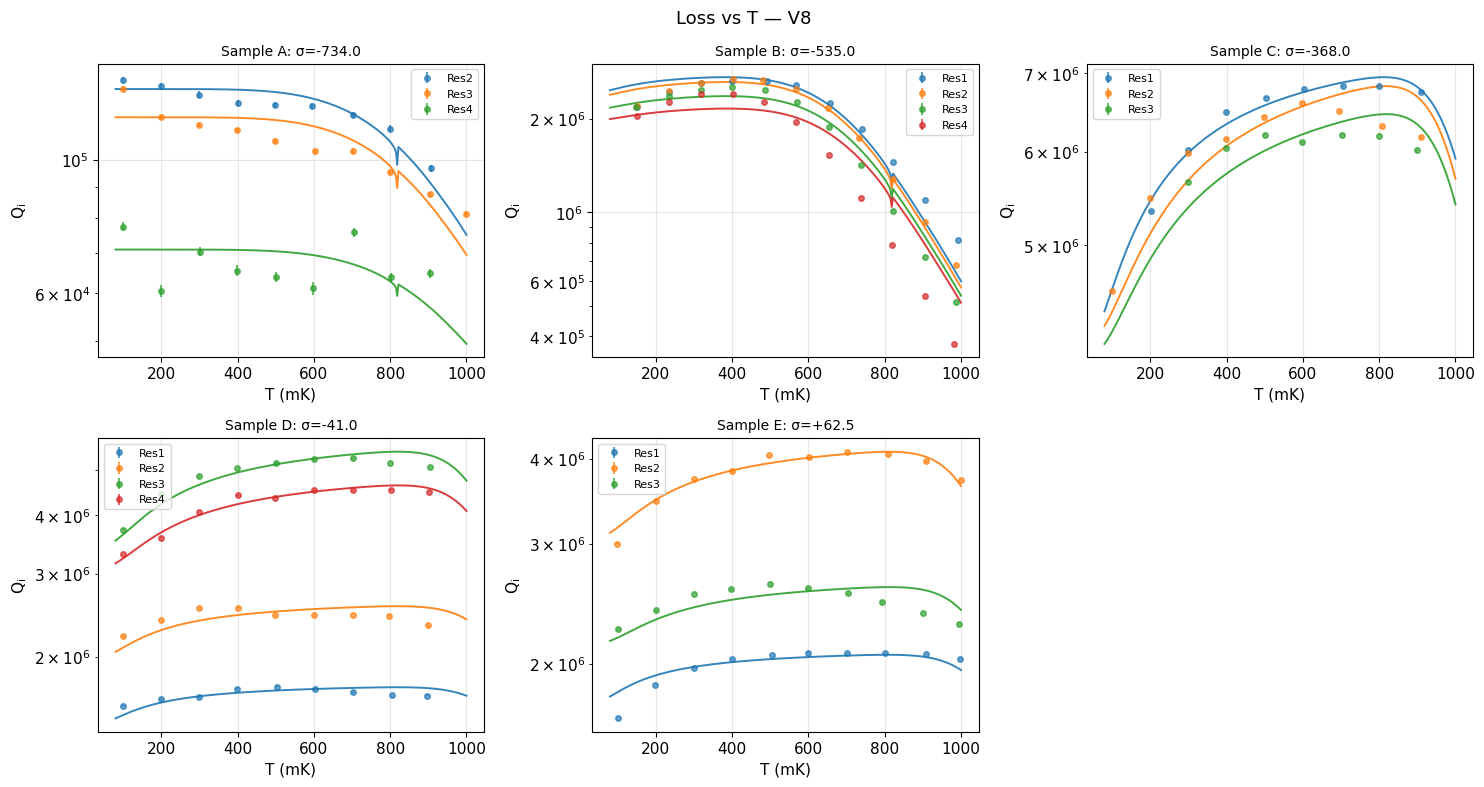

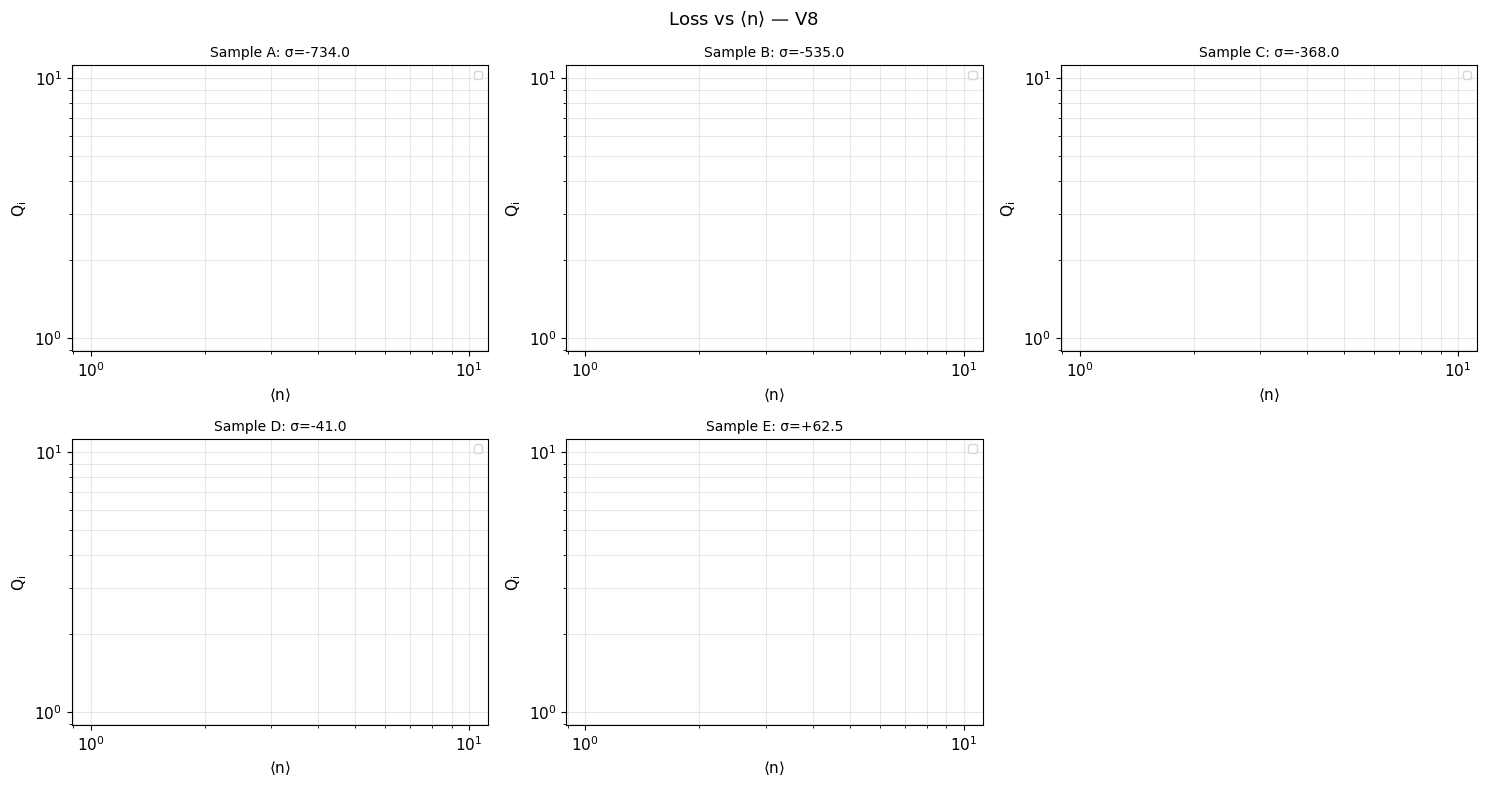

Unconstrained (flat) parameters dropped — data can't pin these:
  f_2·C            (self-curvature -2.38e-05)

Sloppiest combinations among constrained params (smallest λ):
  λ=+3.00e-01 :  +1.00·δ0·A
  λ=+7.33e+01 :  -0.99·f_2·D  -0.10·δ0·D
  λ=+2.63e+02 :  +0.94·f_2·E  +0.24·δ0·E  -0.15·log κ
  λ=+1.14e+03 :  +0.98·δ0·B  +0.12·log κ
  λ=+1.20e+03 :  -0.64·log κ  +0.47·f_2·B  +0.35·f_2·A  +0.34·log s

Most correlated kept pairs (|corr| ≥ 0.9):
  -0.909   log κ          ↔ log s
  -0.936   log κ          ↔ f_2·A
  -0.935   log κ          ↔ f_2·B
  +0.904   log s          ↔ f_2·A
  +0.971   log s          ↔ f_2·B
  +0.912   f_2·A          ↔ f_2·B


{'corr': array([[ 1.00000000e+00,  5.75132825e-02, -9.08580307e-01,
          1.56748142e-04,  1.05459635e-01,  8.47817790e-08,
         -1.27500245e-04, -1.55990125e-04, -9.35547868e-01,
         -9.34825434e-01, -1.87541053e-01, -3.69517702e-01],
        [ 5.75132825e-02,  1.00000000e+00, -6.68572012e-02,
         -1.41153966e-05, -4.95175836e-03,  4.87606748e-09,
         -7.34390587e-06, -8.98287416e-06, -5.68994926e-02,
         -6.14042767e-02, -1.07860860e-02, -2.12521193e-02],
        [-9.08580307e-01, -6.68572012e-02,  1.00000000e+00,
          3.11648596e-04,  9.05648018e-02, -7.70310593e-08,
          1.15844372e-04,  1.41729722e-04,  9.03844071e-01,
          9.71159664e-01,  1.70396107e-01,  3.35736506e-01],
        [ 1.56748142e-04, -1.41153966e-05,  3.11648596e-04,
          1.00000000e+00,  5.01638099e-04,  1.49873572e-11,
         -2.00115019e-08, -2.44506757e-08,  4.34299541e-03,
          1.70463841e-04, -2.93967474e-05, -5.79212144e-05],
        [ 1.05459635e-01, -4

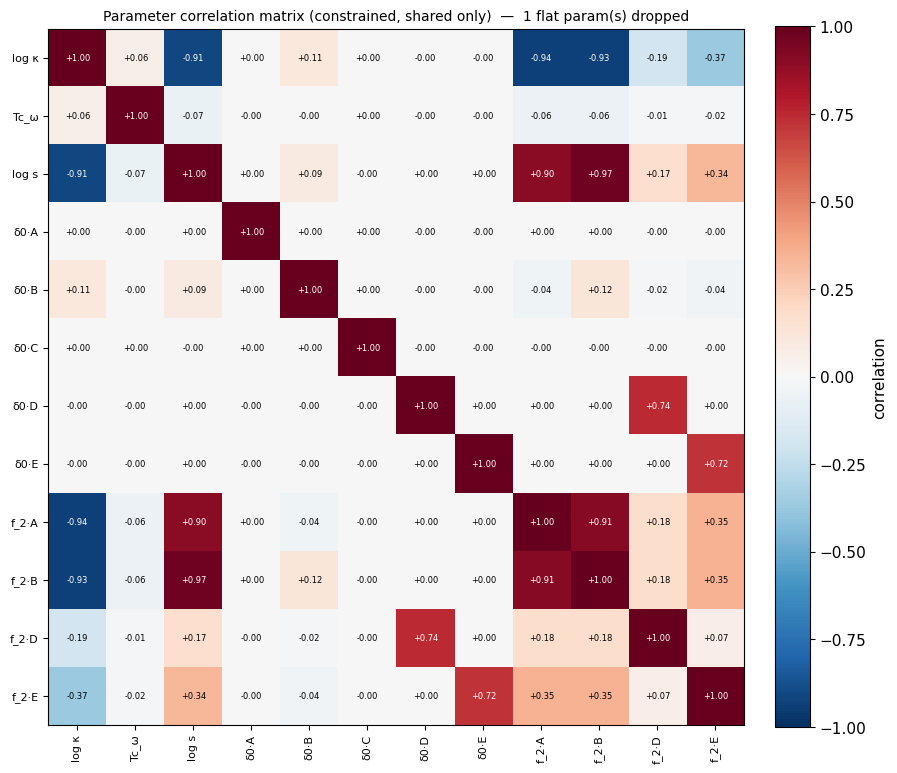

In [4]:
FIT_POWER_CHANNELS = False    # ingest the power data (Loss-P, Freq-P)
FIT_FREQ_T = True           # mute frequency-vs-temperature
FIT_FREQ_P = False            # mute frequency-vs-power  ← new switch
INCLUDE_OMEGA_LOSS = True


fit = run_fit(stress_resonators, popsize=30, de_maxiter=2000)
plot_loss_T(fit); plot_loss_P(fit); plt.show()
parameter_correlation_matrix(fit, shared_only=True)